In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [24]:
data = pd.read_csv("C:/Users/Hp/OneDrive/Desktop/PROJECTS/youtube_performance_updated_dataset.csv")

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   categoryId     200 non-null    int64 
 1   Category_Name  200 non-null    object
 2   publish_hour   200 non-null    int64 
 3   likes          200 non-null    int64 
 4   dislikes       200 non-null    int64 
 5   comment_count  200 non-null    int64 
 6   views          200 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 11.1+ KB


In [26]:
data.describe()

,categoryId,publish_hour,likes,dislikes,comment_count,views
count,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,22.220000,11.260000,101187.020000,5103.380000,10360.040000,1.063253e+06
std,6.023538,7.671811,58477.013998,2756.263419,5517.133553,6.031236e+05
min,10.000000,0.000000,3368.000000,59.000000,109.000000,6.008000e+03
25%,20.000000,4.000000,53688.500000,2831.250000,6135.000000,5.513958e+05
50%,24.000000,11.500000,97332.000000,5054.500000,10288.000000,1.040276e+06
75%,27.000000,18.000000,150502.250000,7327.500000,14804.000000,1.578849e+06
max,28.000000,23.000000,198484.000000,9922.000000,19956.000000,2.386863e+06


In [27]:
data.head()

,categoryId,Category_Name,publish_hour,likes,dislikes,comment_count,views
0,27,Education,23,71316,778,19298,694764
1,23,Comedy,8,3368,1415,19858,238027
2,24,Entertainment,19,78575,4542,15354,937298
3,23,Comedy,16,7655,748,11570,169537
4,23,Comedy,16,71031,7236,1352,554918


In [28]:
data.isnull().sum()

categoryId       0
Category_Name    0
publish_hour     0
likes            0
dislikes         0
comment_count    0
views            0
dtype: int64

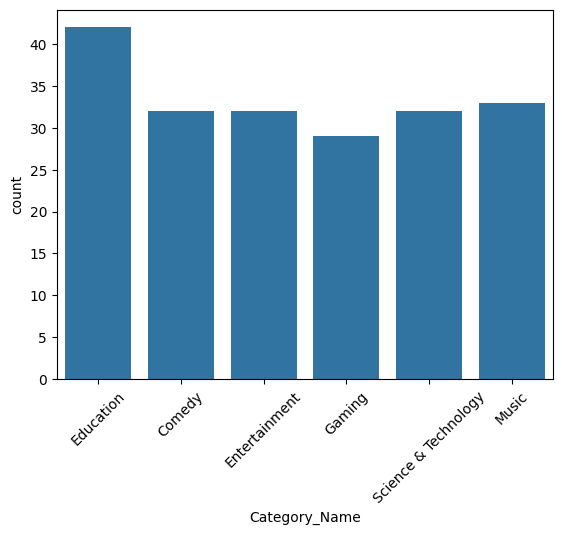

In [29]:
sns.countplot(x="Category_Name", data=data)
plt.xticks(rotation=45)
plt.show()

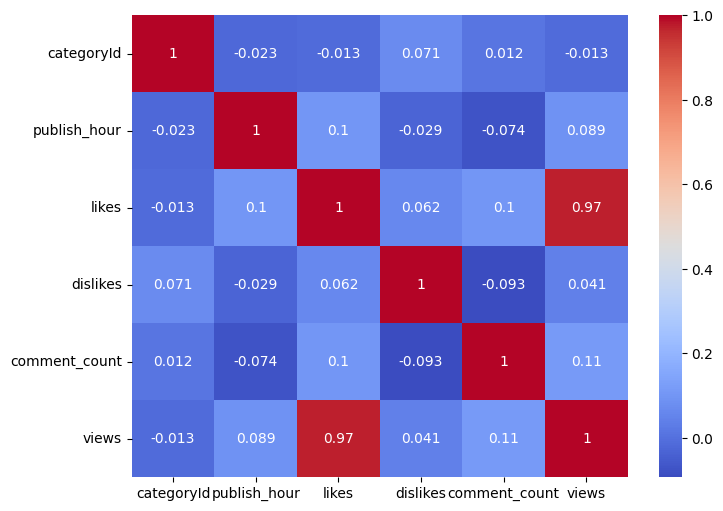

In [30]:
numeric_data = data.select_dtypes(include=['number'])

correlation = numeric_data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

In [31]:
X = data.drop(["views","Category_Name"], axis=1)
y = data["views"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
predictions = model.predict(X_test)

print(predictions)

[2021218.79287742 1859070.5708478  1875997.09915434   92870.95194709
  188994.76367497 1404353.13867993 1175994.77758497  472195.73936291
 1213286.88262533  894502.10767816 1861152.97483325 1931342.98094853
  142222.19427657  732567.90944029  525495.02352431  212002.3949595
 1035684.97307022 1204456.2514884  1964667.65464925 1202734.66699249
 1963179.73871228 1342994.94446243  990750.7211878  1308897.88697161
  277191.81202145  220489.79461639 1916366.59270437 1934873.71183644
 2069574.28490588 1051558.87905628  390173.39053114  274950.09014031
 1406985.01631613  239112.75708035  293107.98158781 1329867.43670068
  429487.96730758  907008.18847842 1404507.01002895 1198572.52660689]


In [35]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("Model Accuracy:", score)

Model Accuracy: 0.9388289429809408


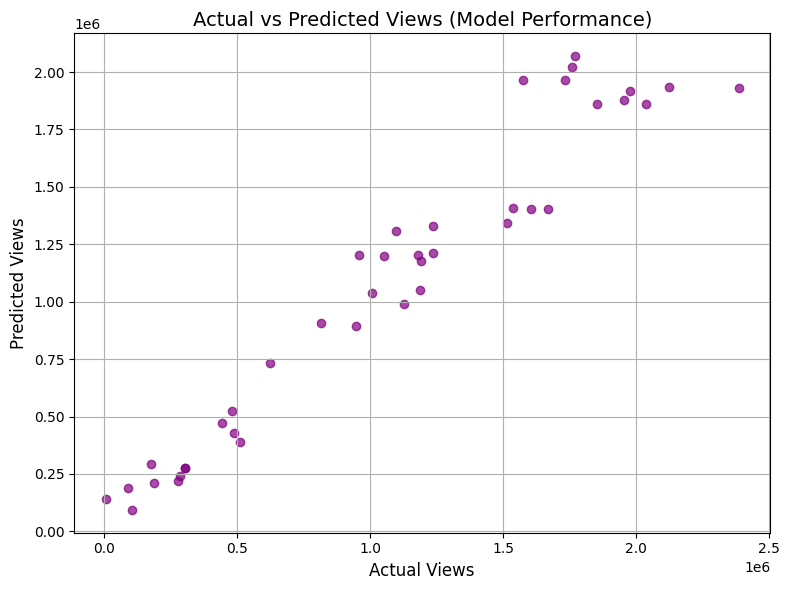

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, color='purple', alpha=0.7)

plt.xlabel("Actual Views", fontsize=12)
plt.ylabel("Predicted Views", fontsize=12)
plt.title("Actual vs Predicted Views (Model Performance)", fontsize=14)

plt.grid(True)

plt.tight_layout()
plt.show()

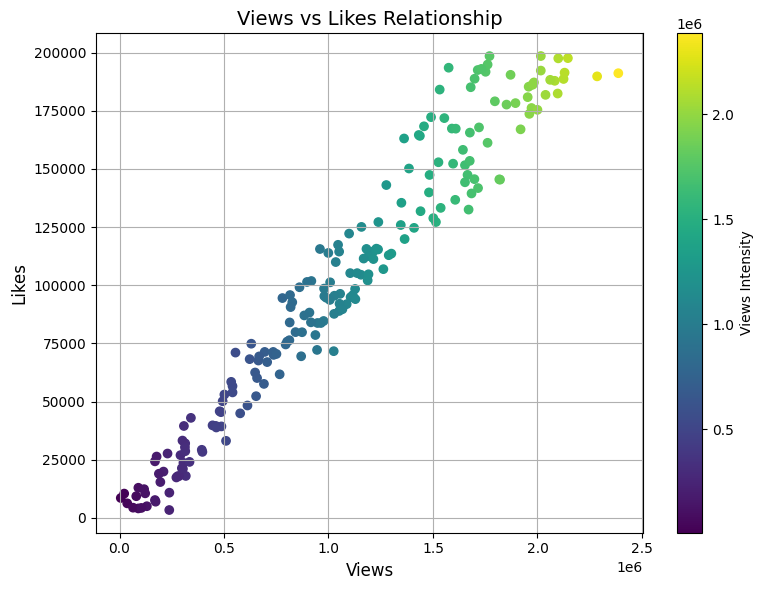

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Color based on views (you can also use likes)
plt.scatter(
    data['views'], 
    data['likes'], 
    c=data['views'],   # color mapping
    cmap='viridis'     # gradient color
)

# Color bar (very important for professional look)
plt.colorbar(label="Views Intensity")

# Labels and title
plt.xlabel("Views", fontsize=12)
plt.ylabel("Likes", fontsize=12)
plt.title("Views vs Likes Relationship", fontsize=14)

plt.grid(True)

plt.tight_layout()
plt.show()

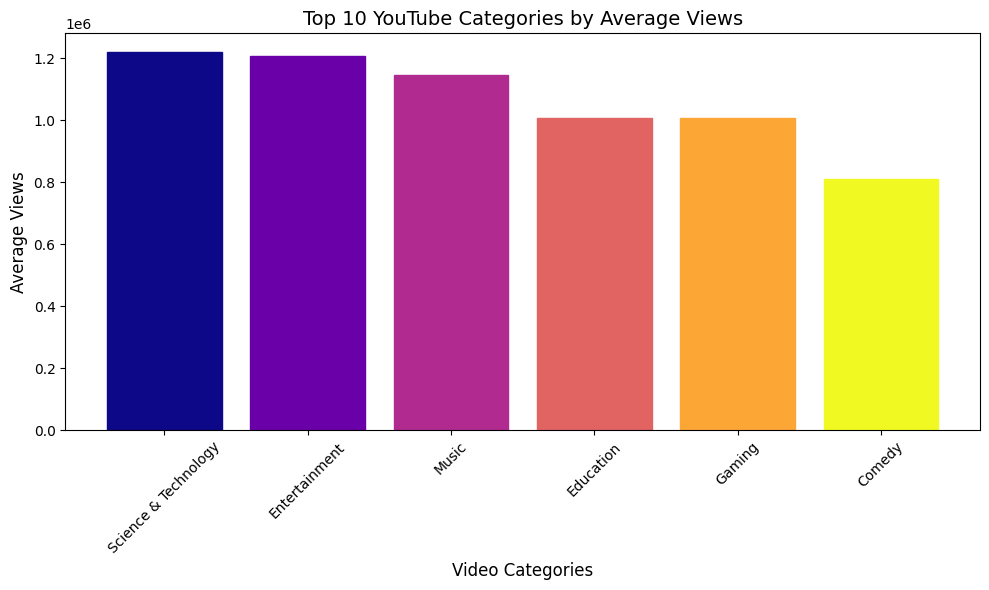

In [43]:
import matplotlib.pyplot as plt
import numpy as np

top_categories = data.groupby('Category_Name')['views'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

# Create bar chart
bars = plt.bar(top_categories.index, top_categories.values)

# Apply different colors
colors = plt.cm.plasma(np.linspace(0, 1, len(bars)))

for bar, color in zip(bars, colors):
    bar.set_color(color)

# Labels and title
plt.xlabel("Video Categories", fontsize=12)
plt.ylabel("Average Views", fontsize=12)
plt.title("Top 10 YouTube Categories by Average Views", fontsize=14)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

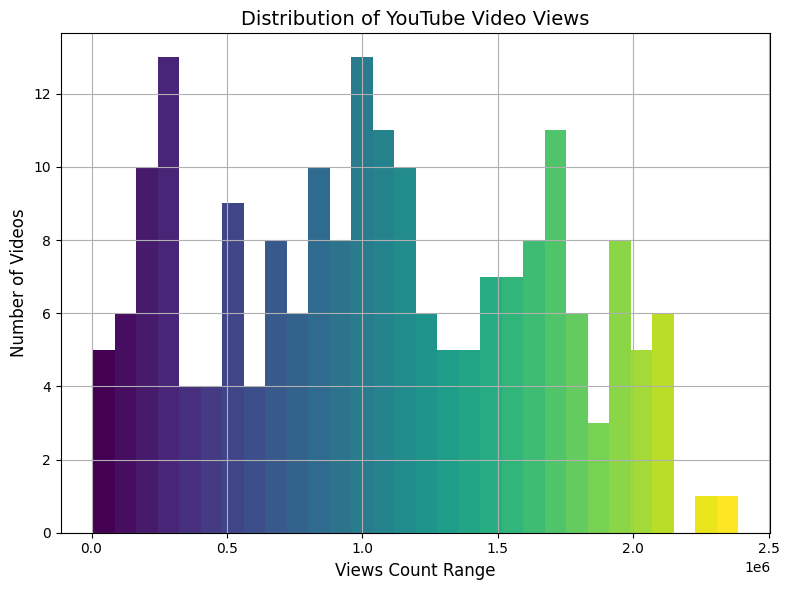

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Create histogram
counts, bins, patches = plt.hist(data['views'], bins=30)

# Apply different colors to each bar
colors = plt.cm.viridis(np.linspace(0, 1, len(patches)))

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

# Labels and title
plt.xlabel("Views Count Range", fontsize=12)
plt.ylabel("Number of Videos", fontsize=12)
plt.title("Distribution of YouTube Video Views", fontsize=14)

plt.grid(True)

plt.tight_layout()
plt.show()